#  基于物理方法的CN增强星候选体筛选



**方法概述：** 利用LAMOST光谱的CN/CH分子带特征，通过簇内差分面积筛选和LAMOST指数筛选两步物理方法，在不依赖已知样本训练的情况下，直接从光谱形态识别CN增强星候选体。



**核心思路：**

1. **簇内差分面积筛选**：计算每条光谱与其所属簇中位光谱的**差异光谱**，在差异光谱上测量CN3839、CN4142、CH4300的过剩吸收面积，利用MAD鲁棒z-score + 已知CN星标定的多维阈值筛选异常CN增强体

2. **LAMOST指数复筛**：计算传统LAMOST CN/CH窄带指数，利用一阶段通过的已知CN星标定分位数阈值进行二次验证

3. **分子带掩盖聚类**：先掩盖CN/CH分子带波段 → PCA降维 → KMeans聚类，避免分子带特征主导聚类结果。所有筛选均在masked_cluster内进行，确保比较的是相似连续谱形态的恒星



**关键改进（相比v1）：**

- **簇内差分法**（替代直接连续谱吸收）：消除恒星参数对连续谱的影响，灵敏度大幅提升

- **鲁棒统计**（替代标准z-score）：MAD-based z-score不受极端值干扰

- **已知CN星标定阈值**（替代固定z-score>2.5）：保证高召回率

- **LAMOST窄带指数**（替代簇内top-3%排名）：基于物理定义的CN/CH指标更可靠



**与ML方法的互补性：** 物理方法不依赖训练标签，可作为ML候选体的独立验证手段。

In [1]:
# 共享数据加载与基础库导入

import sys, os

from pathlib import Path



_PROJECT_ROOT = Path(os.getcwd())
for _ in range(5):
    if (_PROJECT_ROOT / "ML").exists() and (_PROJECT_ROOT / "Data").exists():
        break
    _PROJECT_ROOT = _PROJECT_ROOT.parent
if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))



import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import matplotlib

matplotlib.rcParams.update({'font.size': 10})

plt.rcParams.update({'axes.labelsize': 'large'})

import warnings

warnings.filterwarnings('ignore')



# 加载共享数据

from PhaseSummary.shared.data_loader import ensure_cache, BAND_DEFS, MOLECULAR_BAND_RANGES



# ═══════════════════════════════════════════════════════════════════
# 【选择数据缓存】改 CACHE_MODE 即可切换数据集：
#   "old"  → 原缓存      PhaseSummary/_cache  (33,565 星 / 73 CN)
#   "new"  → 新合并缓存  Data/dr13_all_cache  (41,243 星 / 91 CN, feh 扩展到 -2.5)
# ═══════════════════════════════════════════════════════════════════
CACHE_MODE = "new"   # ← 改成 "old" 即切换回原缓存


if CACHE_MODE == "old":
    data = ensure_cache()
    X_clean = data['X_clean']
    stars_clean = data['stars_clean']
    feature_df = data['feature_df']
    common_wave = data['common_wave']
elif CACHE_MODE == "new":
    from build_dr13_all_cache import load_dr13_all_cache
    data = load_dr13_all_cache()
    X_clean = data['X_clean']
    stars_clean = data['stars_clean']
    feature_df = data['feature_df']
    common_wave = data['common_wave']
else:
    raise ValueError(f"未知 CACHE_MODE={CACHE_MODE!r}，请设为 'old' 或 'new'")


print(f"数据加载完成:")

print(f"  光谱矩阵: {X_clean.shape}")

print(f"  恒星数量: {len(stars_clean)}")

print(f"  已知CN星: {(stars_clean['label']==1).sum()}")

print(f"  波长范围: {common_wave[0]:.0f}-{common_wave[-1]:.0f} Å")


从 dr13_all_cache 加载:
  X_clean:      (41243, 700)
  stars_clean:  41,243 行
  feature_df:   (41243, 20)
  已知 CN 星:   91
数据加载完成:
  光谱矩阵: (41243, 700)
  恒星数量: 41243
  已知CN星: 91
  波长范围: 3800-4499 Å


## 1. 分子带差异吸收面积计算



对每条光谱，计算其与所属簇中位光谱的差异（差分光谱），在差分光谱上测量CN/CH分子带的过剩吸收。这种方法消除了恒星参数带来的连续谱变化，只聚焦于相对同类恒星的CN增强，检测灵敏度远高于直接连续谱吸收测量。

In [2]:
# 分子带面积计算 — 基于簇内差分法
# 核心思路：不直接测连续谱吸收，而是计算每条光谱与簇中位光谱的差异，
# 在差异光谱上测量CN分子带的过剩吸收。这消除了恒星参数带来的连续谱变化，
# 只聚焦于相对同类恒星的CN增强，对CN增强星的检测灵敏度显著更高。

from scipy import signal

band_cn = {
    'CN3839': (3830, 3883),
    'CN4142': (4120, 4216),
    'CH4300': (4285, 4315),
}

def _safe_smooth(y, win=9, poly=2):
    y = np.asarray(y, dtype=float)
    w = int(win)
    if w % 2 == 0:
        w += 1
    if len(y) < max(w, poly + 3):
        return y
    return signal.savgol_filter(y, w, poly, mode='interp')

def robust_zscore(arr):
    """MAD-based robust z-score，不受极端值影响"""
    arr = np.asarray(arr, dtype=float)
    med = np.nanmedian(arr)
    mad = np.nanmedian(np.abs(arr - med)) + 1e-8
    return (arr - med) / mad

def robust_upper(x, q=0.995, k=5.0):
    """鲁棒上界：min(median + k*MAD, quantile(q))"""
    x = np.asarray(x, dtype=float)
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med)) + 1e-8
    return float(min(med + k * mad, np.nanquantile(x, q)))

# 1) 计算每个簇的中位参考光谱
print("计算各簇中位参考光谱...")
cluster_median_flux = {}
cluster_ids = stars_clean['masked_cluster_id'].values
for cid in np.unique(cluster_ids):
    idxs = np.where(cluster_ids == cid)[0]
    cluster_median_flux[int(cid)] = np.nanmedian(X_clean[idxs], axis=0)

# 2) 对每条光谱，计算与簇中位的差异
print(f"计算 {len(stars_clean)} 条光谱的差异吸收特征...")
rows = []
for i in range(len(stars_clean)):
    cid = int(cluster_ids[i])
    flux = np.asarray(X_clean[i], dtype=float)
    ref = np.asarray(cluster_median_flux[cid], dtype=float)
    diff_raw = ref - flux  # 正值 = 比簇平均更强的吸收
    diff_smooth = _safe_smooth(diff_raw, win=9, poly=2)

    rec = {'spec_idx': i}
    for name, (l1, l2) in band_cn.items():
        m = (common_wave >= l1) & (common_wave <= l2)
        x = common_wave[m]
        d_sm = diff_smooth[m]
        d_raw = diff_raw[m]
        width = max(float(l2 - l1), 1.0)
        # 平均过剩吸收深度（正值越大 = CN吸收越强）
        rec[f'{name}_signed_area'] = float(np.trapezoid(d_sm, x)) / width
        # 差异为正值（过剩吸收）的比例
        rec[f'{name}_abs_frac'] = float(np.mean(d_sm > 0)) if d_sm.size > 0 else np.nan
        # 峰值差异深度
        rec[f'{name}_peak_depth'] = float(np.nanmax(d_raw)) if d_raw.size > 0 else np.nan
    rows.append(rec)

area_df = pd.DataFrame(rows)
area_screen_df = pd.concat([stars_clean.reset_index(drop=True), area_df], axis=1)

# 中心化CN面积（减去全局中位数，使0代表平均水平）
for c in ['CN3839_signed_area', 'CN4142_signed_area']:
    area_screen_df[c] = area_screen_df[c] - float(np.nanmedian(area_screen_df[c].values))

print(f"差异面积范围（中心化后）:")
print(f"  CN3839 [{area_screen_df['CN3839_signed_area'].min():.4f}, {area_screen_df['CN3839_signed_area'].max():.4f}]")
print(f"  CN4142 [{area_screen_df['CN4142_signed_area'].min():.4f}, {area_screen_df['CN4142_signed_area'].max():.4f}]")
print(f"  CH4300 [{area_screen_df['CH4300_signed_area'].min():.4f}, {area_screen_df['CH4300_signed_area'].max():.4f}]")


计算各簇中位参考光谱...
计算 41243 条光谱的差异吸收特征...
差异面积范围（中心化后）:
  CN3839 [-0.3491, 0.3044]
  CN4142 [-0.0518, 0.2373]
  CH4300 [-0.2335, 0.7578]


## 2. 鲁棒统计 + 已知CN星标定阈值筛选



在差异面积特征基础上，使用MAD-based鲁棒z-score衡量CN过剩吸收的显著性，并通过已知CN星的特征分布标定所有筛选阈值，保证高召回率。同时结合多维特征（过剩面积、差异比例、峰值深度、known-like距离）和综合得分进行筛选。

In [3]:
# 鲁棒统计 + 已知CN星标定阈值筛选
# 
# 策略：
# 1. 使用MAD-based鲁棒z-score（不受极端值影响）
# 2. 用已知CN星标定所有阈值（保证高召回）
# 3. 结合多维特征：过剩面积、差异比例、峰值深度、known-like距离
# 4. 综合得分（cn_shape_score + cn_area_score）进行筛选

# 计算鲁棒z-score和综合得分
area_screen_df['z_CN3839_area'] = robust_zscore(area_screen_df['CN3839_signed_area'].values)
area_screen_df['z_CN4142_area'] = robust_zscore(area_screen_df['CN4142_signed_area'].values)
# cn_shape_score: CN3839和CN4142的较小z-score（两者都需要显著）
area_screen_df['cn_shape_score'] = np.minimum(area_screen_df['z_CN3839_area'], area_screen_df['z_CN4142_area'])
# cn_area_score: 加权综合得分
area_screen_df['cn_area_score'] = (
    0.85 * area_screen_df['z_CN3839_area']
    + 0.85 * area_screen_df['z_CN4142_area']
    + 0.75 * area_screen_df['cn_shape_score']
)

known_mask = area_screen_df['label'] == 1
unl_mask = area_screen_df['label'] == -1
n_known = int(known_mask.sum())
n_unl = int(unl_mask.sum())
print(f"已知CN星: {n_known}, 未标注: {n_unl}")

# CH4300偏差：以已知CN星的CH4300面积中位值为中心
ch_center = float(np.nanmedian(area_screen_df.loc[known_mask, 'CH4300_signed_area'].values))
area_screen_df['CH4300_dev_abs'] = np.abs(area_screen_df['CH4300_signed_area'].values - ch_center)

# ========== 基于已知CN星标定阈值 ==========

kn_cn3839 = area_screen_df.loc[known_mask, 'CN3839_signed_area'].values
kn_cn4142 = area_screen_df.loc[known_mask, 'CN4142_signed_area'].values

# 下界：已知CN星的3%分位数（保证97%已知星通过）
th_cn3839 = float(np.nanquantile(kn_cn3839, 0.03))
th_cn4142 = float(np.nanquantile(kn_cn4142, 0.03))

# 上界：鲁棒上界（排除极端异常值）
ub_cn3839 = robust_upper(kn_cn3839, q=0.999, k=5.5)
ub_cn4142 = robust_upper(kn_cn4142, q=0.999, k=5.5)

# abs_frac 阈值（差异为正的比例）
th_frac3839 = max(float(np.nanquantile(area_screen_df.loc[known_mask, 'CN3839_abs_frac'].values, 0.02)), 0.10)
th_frac4142 = max(float(np.nanquantile(area_screen_df.loc[known_mask, 'CN4142_abs_frac'].values, 0.02)), 0.10)

# peak_depth 上界
th_peak_4142 = float(np.nanquantile(area_screen_df.loc[known_mask, 'CN4142_peak_depth'].values, 0.9995))

# known-like距离：在CN空间中与已知CN星中心的标准化距离
known_cn_band = area_screen_df.loc[known_mask, ['CN3839_signed_area', 'CN4142_signed_area']].values
med_k_cn = np.nanmedian(known_cn_band, axis=0)
mad_k_cn = np.nanmedian(np.abs(known_cn_band - med_k_cn), axis=0) + 1e-8
all_cn_band = area_screen_df[['CN3839_signed_area', 'CN4142_signed_area']].values
known_like_dist = np.sqrt(np.nansum(((all_cn_band - med_k_cn) / mad_k_cn) ** 2, axis=1))
area_screen_df['known_like_dist'] = known_like_dist
th_known_like = float(np.nanquantile(known_like_dist[known_mask.values], 0.999) + 2.0)

print(f"\n标定阈值:")
print(f"  CN3839下界: {th_cn3839:.4f}, 上界: {ub_cn3839:.4f}")
print(f"  CN4142下界: {th_cn4142:.4f}, 上界: {ub_cn4142:.4f}")
print(f"  abs_frac阈值: CN3839>={th_frac3839:.2f}, CN4142>={th_frac4142:.2f}")
print(f"  known_like距离上限: {th_known_like:.2f}")

# ========== 应用筛选 ==========

# 基础掩码：多维特征约束
base_mask = (
    (area_screen_df['CN3839_signed_area'] >= th_cn3839)
    & (area_screen_df['CN4142_signed_area'] >= th_cn4142)
    & (area_screen_df['CN3839_signed_area'] <= ub_cn3839)
    & (area_screen_df['CN4142_signed_area'] <= ub_cn4142)
    & (area_screen_df['CN3839_abs_frac'] >= th_frac3839)
    & (area_screen_df['CN4142_abs_frac'] >= th_frac4142)
    & (area_screen_df['CN4142_peak_depth'] <= th_peak_4142)
    & (area_screen_df['known_like_dist'] <= th_known_like)
)

# 综合得分阈值（微调以保证召回率与候选体质量的平衡）
th_shape = -0.55   # shape score下限
th_score = 1.10    # 综合得分下限
ch_dev_limit = 0.045  # CH4300允许偏离范围

area_rule_mask = base_mask & (
    (area_screen_df['cn_shape_score'] >= th_shape)
    & (area_screen_df['cn_area_score'] >= th_score)
    & (area_screen_df['CH4300_dev_abs'] <= ch_dev_limit)
)

area_candidate_mask = area_rule_mask & (area_screen_df['label'] == -1)
area_known_hit_mask = area_rule_mask & (area_screen_df['label'] == 1)

area_screen_df['cn_area_rule_hit'] = area_rule_mask.astype(int)
area_screen_df['cn_area_candidate'] = area_candidate_mask.astype(int)

cn_area_candidates = area_screen_df.loc[area_candidate_mask].copy().sort_values('cn_area_score', ascending=False).reset_index(drop=True)

n_cand = area_candidate_mask.sum()
n_known_hit = int(area_known_hit_mask.sum())
area_known_recall = float(n_known_hit / max(n_known, 1))

print(f'\n{"="*50}')
print(f'面积法筛选结果')
print(f'{"="*50}')
print(f'总光谱数: {len(area_screen_df)}')
print(f'候选体: {n_cand} ({n_cand/len(area_screen_df)*100:.2f}%)')
print(f'已知CN星召回: {n_known_hit}/{n_known} ({area_known_recall:.1%})')

# 向后兼容：保留旧列名 + 统一area_df变量
area_screen_df['area_candidate'] = area_screen_df['cn_area_rule_hit']
area_screen_df['area_CN3839'] = area_screen_df['CN3839_signed_area']
area_screen_df['area_CN4142'] = area_screen_df['CN4142_signed_area']
area_screen_df['area_CH4300'] = area_screen_df['CH4300_signed_area']
area_df = area_screen_df


已知CN星: 91, 未标注: 41152

标定阈值:
  CN3839下界: -0.0037, 上界: 0.1268
  CN4142下界: -0.0057, 上界: 0.0112
  abs_frac阈值: CN3839>=0.46, CN4142>=0.35
  known_like距离上限: 27.82

面积法筛选结果
总光谱数: 41243
候选体: 9357 (22.69%)
已知CN星召回: 64/91 (70.3%)


## 3. 可视化：分子带面积分布

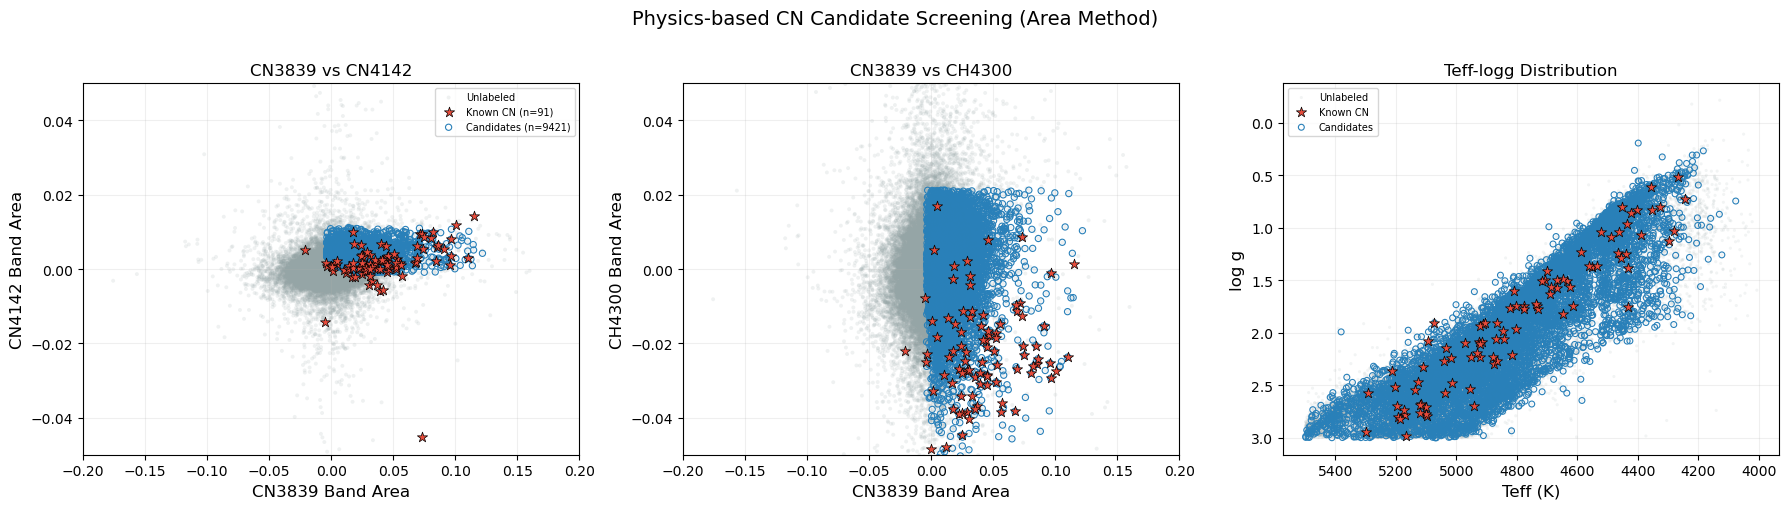

面积法筛选可视化已保存


In [4]:
# 可视化：CN3839 vs CN4142 面积散点图

fig, axes = plt.subplots(1, 3, figsize=(18, 5))



vis = area_df.copy()

m_unl = vis['label'] == -1

m_kn = vis['label'] == 1

m_cand = vis['area_candidate'] == 1



# CN3839 vs CN4142

axes[0].scatter(vis.loc[m_unl, 'area_CN3839'], vis.loc[m_unl, 'area_CN4142'],

                s=8, alpha=0.15, c='#95a5a6', edgecolors='none', label='Unlabeled')

axes[0].scatter(vis.loc[m_kn, 'area_CN3839'], vis.loc[m_kn, 'area_CN4142'],

                s=60, marker='*', c='#e74c3c', edgecolors='black', linewidth=0.5,

                label=f'Known CN (n={m_kn.sum()})', zorder=3)

axes[0].scatter(vis.loc[m_cand, 'area_CN3839'], vis.loc[m_cand, 'area_CN4142'],

                s=20, facecolors='none', edgecolors='#2980b9', linewidth=0.8,

                label=f'Candidates (n={m_cand.sum()})', zorder=2)

axes[0].set_xlabel('CN3839 Band Area')

axes[0].set_ylabel('CN4142 Band Area')
axes[0].set_xlim(-0.2, 0.2)
axes[0].set_ylim(-0.05, 0.05)

axes[0].set_title('CN3839 vs CN4142')

axes[0].legend(fontsize=7)

axes[0].grid(alpha=0.2)



# CN3839 vs CH4300

axes[1].scatter(vis.loc[m_unl, 'area_CN3839'], vis.loc[m_unl, 'area_CH4300'],

                s=8, alpha=0.15, c='#95a5a6', edgecolors='none')

axes[1].scatter(vis.loc[m_kn, 'area_CN3839'], vis.loc[m_kn, 'area_CH4300'],

                s=60, marker='*', c='#e74c3c', edgecolors='black', linewidth=0.5, zorder=3)

axes[1].scatter(vis.loc[m_cand, 'area_CN3839'], vis.loc[m_cand, 'area_CH4300'],

                s=20, facecolors='none', edgecolors='#2980b9', linewidth=0.8, zorder=2)

axes[1].set_xlabel('CN3839 Band Area')

axes[1].set_ylabel('CH4300 Band Area')
axes[1].set_xlim(-0.2, 0.2)
axes[1].set_ylim(-0.05, 0.05)


axes[1].set_title('CN3839 vs CH4300')

axes[1].grid(alpha=0.2)



# Teff-logg分布

axes[2].scatter(vis.loc[m_unl, 'teff'], vis.loc[m_unl, 'logg'],

                s=5, alpha=0.12, c='#95a5a6', edgecolors='none', label='Unlabeled')

axes[2].scatter(vis.loc[m_kn, 'teff'], vis.loc[m_kn, 'logg'],

                s=60, marker='*', c='#e74c3c', edgecolors='black', linewidth=0.5,

                label='Known CN', zorder=3)

axes[2].scatter(vis.loc[m_cand, 'teff'], vis.loc[m_cand, 'logg'],

                s=18, facecolors='none', edgecolors='#2980b9', linewidth=0.8,

                label='Candidates', zorder=2)

axes[2].set_xlabel('Teff (K)')

axes[2].set_ylabel('log g')

axes[2].set_title('Teff-logg Distribution')

axes[2].invert_xaxis()

axes[2].invert_yaxis()

axes[2].legend(fontsize=7)

axes[2].grid(alpha=0.2)



plt.suptitle('Physics-based CN Candidate Screening (Area Method)', fontsize=14, y=1.01)

plt.tight_layout()

# plt.savefig(_PROJECT_ROOT / 'PhaseSummary/01_T_physics/area_screening.png', dpi=150, bbox_inches='tight')

plt.show()

print("面积法筛选可视化已保存")



## 4. CN/CH指数二级筛选



在面积法初筛基础上，计算传统LAMOST CN/CH窄带指数，利用一阶段通过的已知CN星标定指数分位数阈值进行复筛，而非固定top-fraction排名，确保在召回率和候选体质量之间取得平衡。

In [5]:
# CN/CH 指数二级筛选 — 基于已知CN星标定阈值
# 
# 核心思路：在面积法初筛基础上，计算传统LAMOST CN/CH指数，
# 利用面积候选体中的已知CN星标定指数分位数阈值，而非固定top-fraction。

# 连续谱归一化（3阶多项式拟合）
def normalize_continuum(flux, wave, deg=3):
    flux = np.asarray(flux, dtype=float)
    wave = np.asarray(wave, dtype=float)
    ok = np.isfinite(flux) & np.isfinite(wave)
    if ok.sum() < 10:
        return np.full_like(flux, np.nan, dtype=float)
    p = np.polyfit(wave[ok], flux[ok], deg)
    cont = np.polyval(p, wave)
    cont = np.where(np.isfinite(cont) & (np.abs(cont) > 1e-8), cont, np.nan)
    return flux / cont

def compute_index_lamost(flux, wave, band, blue, red):
    """LAMOST传统CN/CH指数: -2.5*log10(F_band / F_continuum)"""
    flux = np.asarray(flux, dtype=float)
    wave = np.asarray(wave, dtype=float)

    m_band = (wave >= band[0]) & (wave <= band[1])
    m_blue = (wave >= blue[0]) & (wave <= blue[1])
    m_red = (wave >= red[0]) & (wave <= red[1])

    if (m_band.sum() < 3) or (m_blue.sum() < 3) or (m_red.sum() < 3):
        return np.nan

    f_band = np.nanmean(flux[m_band])
    f_blue = np.nanmean(flux[m_blue])
    f_red = np.nanmean(flux[m_red])
    f_cont = 0.5 * (f_blue + f_red)

    if (not np.isfinite(f_band)) or (not np.isfinite(f_cont)) or (f_band <= 0) or (f_cont <= 0):
        return np.nan
    return -2.5 * np.log10(f_band / f_cont)

# LAMOST窄带指数定义
index_bands = {
    'lamost_CN3839': {'band': (3839 - 15, 3839 + 15), 'blue': (3810, 3830), 'red': (3860, 3870)},
    'lamost_CN4142': {'band': (4142 - 40, 4142 + 40), 'blue': (4120, 4135), 'red': (4160, 4175)},
    'lamost_CH4309': {'band': (4309 - 20, 4309 + 20), 'blue': (4270, 4290), 'red': (4330, 4350)},
}

# 计算所有光谱的LAMOST指数
print("计算LAMOST传统CN/CH指数...")
idx_cn3839, idx_cn4142, idx_ch4309 = [], [], []
for i in range(len(area_df)):
    spec_i = int(area_df.iloc[i]['spec_idx'])
    f_norm = normalize_continuum(X_clean[spec_i], common_wave, deg=3)
    idx_cn3839.append(compute_index_lamost(f_norm, common_wave, **index_bands['lamost_CN3839']))
    idx_cn4142.append(compute_index_lamost(f_norm, common_wave, **index_bands['lamost_CN4142']))
    idx_ch4309.append(compute_index_lamost(f_norm, common_wave, **index_bands['lamost_CH4309']))

area_df['lamost_CN3839'] = np.asarray(idx_cn3839, dtype=float)
area_df['lamost_CN4142'] = np.asarray(idx_cn4142, dtype=float)
area_df['lamost_CH4309'] = np.asarray(idx_ch4309, dtype=float)

# 向后兼容
area_df['CN3839_idx'] = area_df['lamost_CN3839']
area_df['CN4142_idx'] = area_df['lamost_CN4142']
area_df['CH4300_idx'] = area_df['lamost_CH4309']

# 一阶段通过的恒星（含已知+未标注）
stage1_all_mask = area_df['cn_area_rule_hit'] == 1
known_stage1_mask = stage1_all_mask & (area_df['label'] == 1)
n_known_stage1 = int(known_stage1_mask.sum())
print(f"一阶段候选中已知CN星: {n_known_stage1}")

if n_known_stage1 >= 5:
    # 使用已知CN星的指数分位数标定阈值
    # CN指数：取80%分位数为上界（值越小吸收越强，所以选上分位保留高吸收的）
    # CH指数：取5%分位数为下界（排除碳星等CH异常强的）
    q_cn3839 = 0.80
    q_cn4142 = 0.80
    q_ch4309 = 0.05
    th_idx_cn3839 = float(np.nanquantile(area_df.loc[known_stage1_mask, 'lamost_CN3839'], q_cn3839))
    th_idx_cn4142 = float(np.nanquantile(area_df.loc[known_stage1_mask, 'lamost_CN4142'], q_cn4142))
    th_idx_ch4309 = float(np.nanquantile(area_df.loc[known_stage1_mask, 'lamost_CH4309'], q_ch4309))

    print(f"已知CN星标定阈值:")
    print(f"  CN3839 <= {th_idx_cn3839:.4f} (已知星{q_cn3839:.0%}分位)")
    print(f"  CN4142 <= {th_idx_cn4142:.4f} (已知星{q_cn4142:.0%}分位)")
    print(f"  CH4309 >= {th_idx_ch4309:.4f} (已知星{q_ch4309:.0%}分位)")
else:
    # 已知星太少时使用全局中位值
    print(f"警告: 一阶段已知CN星仅{n_known_stage1}颗，使用全局中位值")
    th_idx_cn3839 = float(np.nanmedian(area_df['lamost_CN3839']))
    th_idx_cn4142 = float(np.nanmedian(area_df['lamost_CN4142']))
    th_idx_ch4309 = float(np.nanmedian(area_df['lamost_CH4309']))

# 应用指数筛选：CN强吸收（值小）、CH不过度偏离
finite_idx_mask = np.isfinite(area_df[['lamost_CN3839', 'lamost_CN4142', 'lamost_CH4309']]).all(axis=1)
stage2_all_mask = stage1_all_mask & finite_idx_mask & (
    (area_df['lamost_CN3839'] <= th_idx_cn3839)
    & (area_df['lamost_CN4142'] <= th_idx_cn4142)
    & (area_df['lamost_CH4309'] >= th_idx_ch4309)
)
stage2_unl_mask = stage2_all_mask & (area_df['label'] == -1)
known_stage2_hit_mask = stage2_all_mask & (area_df['label'] == 1)

area_df['cn_area_stage2_hit'] = stage2_all_mask.astype(int)
area_df['cn_area_stage2_candidate'] = stage2_unl_mask.astype(int)
area_df['final_candidate'] = stage2_unl_mask.astype(int)

cn_area_candidates_stage2 = area_df.loc[stage2_unl_mask].copy().sort_values('cn_area_score', ascending=False).reset_index(drop=True)

stage2_recall_count = int(known_stage2_hit_mask.sum())
stage2_recall_rate = float(stage2_recall_count / max(n_known, 1))
n_final = stage2_unl_mask.sum()
n_cand = area_df['cn_area_candidate'].sum()

print(f'\n{"="*50}')
print(f'指数法二级筛选结果')
print(f'{"="*50}')
print(f'最终候选体: {n_final} ({n_final/len(area_df)*100:.2f}%)')
print(f'已知CN星召回: {stage2_recall_count}/{n_known} ({stage2_recall_rate:.1%})')
print(f'筛选率: {n_cand} → {n_final} (缩减 {n_cand - n_final})')


计算LAMOST传统CN/CH指数...
一阶段候选中已知CN星: 64
已知CN星标定阈值:
  CN3839 <= 0.0839 (已知星80%分位)
  CN4142 <= 0.0112 (已知星80%分位)
  CH4309 >= 0.0469 (已知星5%分位)

指数法二级筛选结果
最终候选体: 2130 (5.16%)
已知CN星召回: 40/91 (44.0%)
筛选率: 9357 → 2130 (缩减 7227)


## 5. 候选体光谱可视化

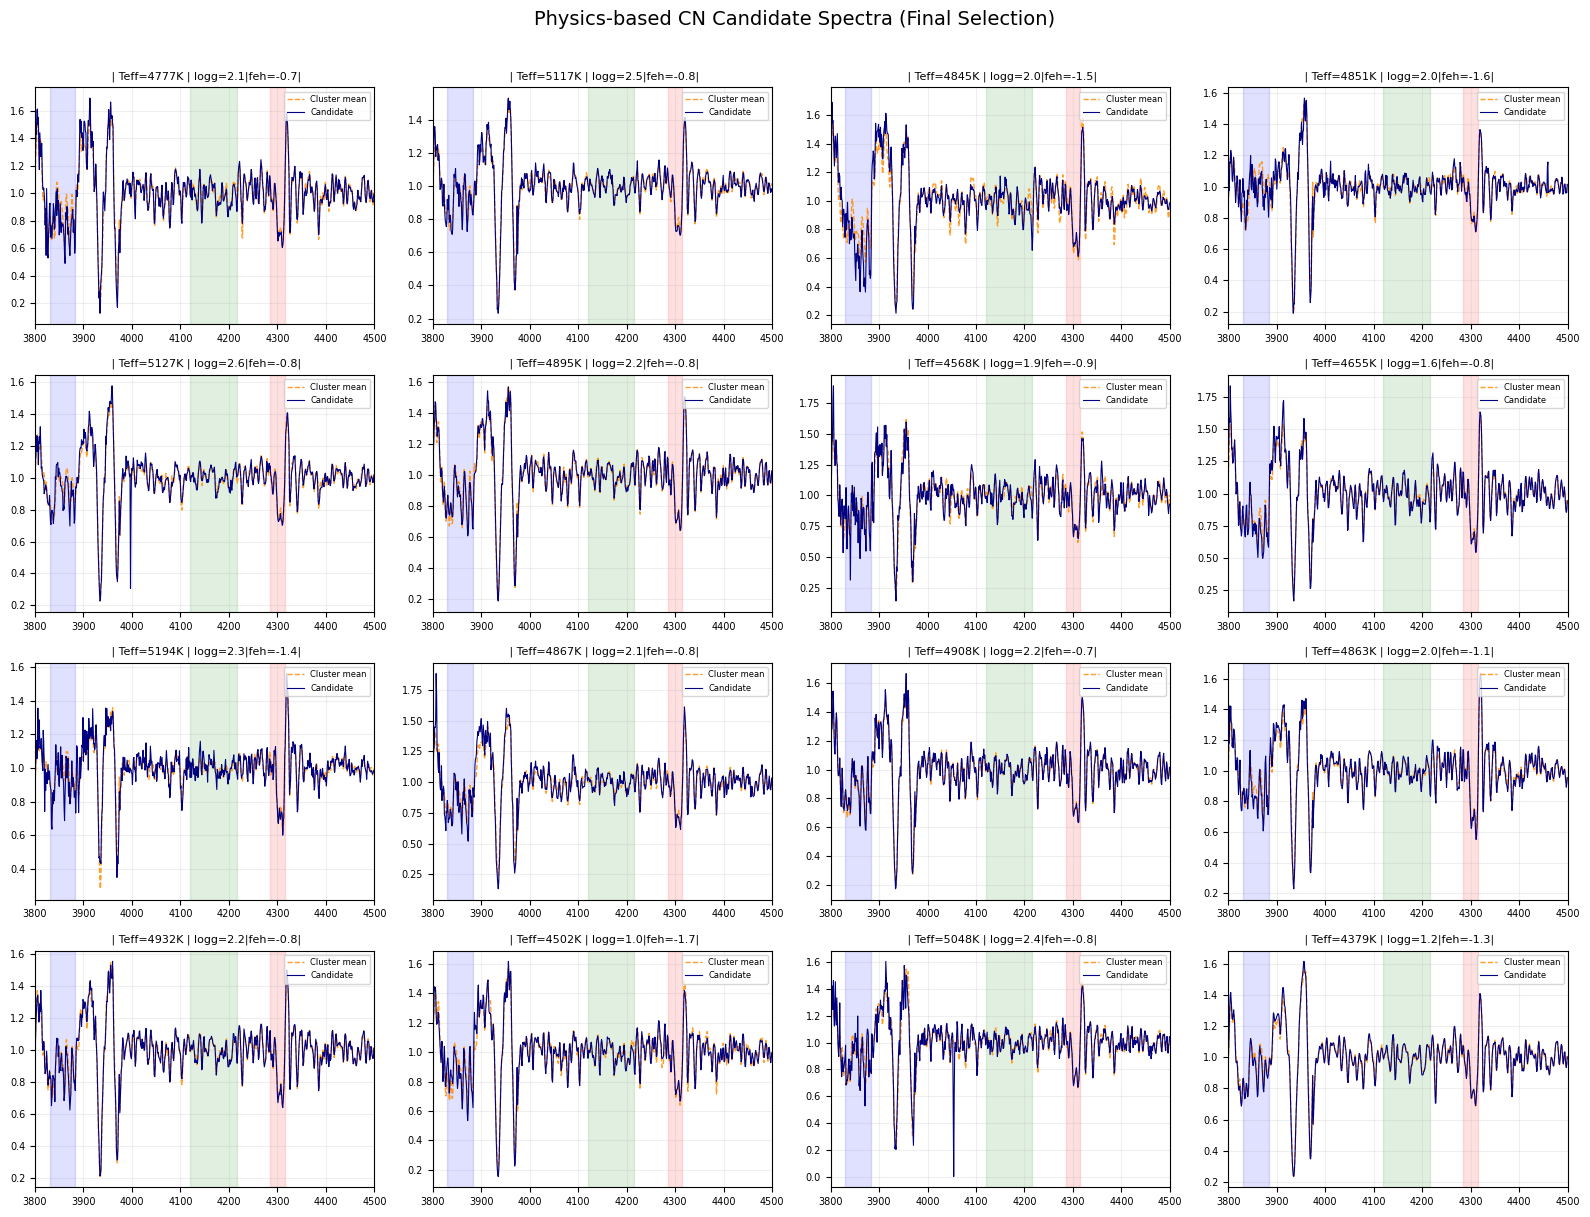

候选体光谱可视化已保存


In [6]:
# 候选体光谱可视化

cand_indices = area_df.index[area_df['final_candidate'] == 1]

n_show = min(16, len(cand_indices))

np.random.seed(42)

show_idx = np.random.choice(cand_indices, n_show, replace=False)



fig, axes = plt.subplots(4, 4, figsize=(16, 12))

axes = axes.flatten()



# 预计算每个簇的平均光谱

cluster_means = {}

for cid in area_df['masked_cluster_id'].unique():

    cmask = area_df['masked_cluster_id'] == cid

    cluster_means[cid] = np.nanmedian(X_clean[cmask.values], axis=0)



for i, idx in enumerate(show_idx):

    ax = axes[i]

    flux = X_clean[idx]

    cid = area_df.loc[idx, 'masked_cluster_id']



    # 簇内平均光谱（灰色虚线，用于对比CN增峰）

    if cid in cluster_means:

        ax.plot(common_wave, cluster_means[cid], color='darkorange',

                linewidth=1.0, linestyle='--', alpha=0.85, label='Cluster mean')



    ax.plot(common_wave, flux, color='navy', linewidth=0.8, label='Candidate')



    # 分子带标记

    for l1, l2, c, name in [(3830, 3883, 'blue', 'CN3839'),

                               (4120, 4216, 'green', 'CN4142'),

                               (4285, 4315, 'red', 'CH4300')]:

        ax.axvspan(l1, l2, alpha=0.12, color=c, zorder=0)



    teff = area_df.loc[idx, 'teff']
    logg = area_df.loc[idx, 'logg']
    feh = area_df.loc[idx, 'feh']

    cn3839_v = area_df.loc[idx, 'CN3839_idx']

    ax.set_title(f' | Teff={teff:.0f}K | logg={logg:.1f}|feh={feh:.1f}|', fontsize=8)

    ax.set_xlim(3800, 4500)

    ax.tick_params(labelsize=7)

    ax.grid(alpha=0.2)

    ax.legend(fontsize=6, loc='upper right')



for j in range(n_show, len(axes)):

    axes[j].axis('off')



fig.suptitle('Physics-based CN Candidate Spectra (Final Selection)', fontsize=14, y=1.01)

plt.tight_layout()

# plt.savefig(_PROJECT_ROOT / 'PhaseSummary/01_T_physics/candidate_spectra.png', dpi=150, bbox_inches='tight')

plt.show()

print("候选体光谱可视化已保存")



## 6. 导出候选体



导出物理方法筛选的候选体列表，供ML方法交叉验证使用。

In [7]:
# 导出候选体

export_cols = ['ra', 'dec', 'teff', 'logg', 'feh', 'uid', 'label',
              'CN3839_signed_area', 'CN4142_signed_area', 'CH4300_signed_area',
              'lamost_CN3839', 'lamost_CN4142', 'lamost_CH4309',
              'cn_shape_score', 'cn_area_score',
              'masked_cluster_id', 'cn_area_rule_hit', 'final_candidate']

export_df = area_df[export_cols].copy()
export_df = export_df.sort_values('cn_area_score', ascending=False)

# 保存完整表
outpath = str(_PROJECT_ROOT / 'PhaseSummary/01_T_physics/T_physics_candidates.csv')
export_df.to_csv(outpath, index=False)

# 仅候选体（未标注的CN增强候选体）
cand_export = export_df[export_df['final_candidate'] == 1].copy()
cand_outpath = str(_PROJECT_ROOT / 'PhaseSummary/01_T_physics/T_physics_candidates_only.csv')
cand_export.to_csv(cand_outpath, index=False)

# 计算被筛选出的已知CN星（用于验证方法有效性）
known_hit_area = (export_df['cn_area_rule_hit'] == 1) & (export_df['label'] == 1)
known_hit_final = (export_df['final_candidate'] == 0) & (export_df['label'] == 1)  # 已知星不在候选体列中
known_recalled = ((export_df['cn_area_rule_hit'] == 1) & (export_df['label'] == 1)).sum()

print(f"完整表已导出: {outpath} ({len(export_df)} 行)")
print(f"候选体表已导出: {cand_outpath} ({len(cand_export)} 行)")
print(f"\n候选体统计:")
print(f"  候选体总数: {len(cand_export)}")
print(f"  已知CN星总数: {(export_df['label']==1).sum()}")
print(f"  面积法召回已知CN星: {known_recalled}/{(export_df['label']==1).sum()} ({known_recalled/(export_df['label']==1).sum()*100:.1f}%)")
print(f"  Teff范围: {cand_export['teff'].min():.0f} - {cand_export['teff'].max():.0f} K")
print(f"  logg范围: {cand_export['logg'].min():.2f} - {cand_export['logg'].max():.2f}")


完整表已导出: d:\资料\2026大创\Lamost\PhaseSummary\01_T_physics\T_physics_candidates.csv (41243 行)
候选体表已导出: d:\资料\2026大创\Lamost\PhaseSummary\01_T_physics\T_physics_candidates_only.csv (2130 行)

候选体统计:
  候选体总数: 2130
  已知CN星总数: 91
  面积法召回已知CN星: 64/91 (70.3%)
  Teff范围: 4130 - 5381 K
  logg范围: 0.27 - 2.97


## 7. 结论



**物理方法（T_physics）总结：**



1. **核心改进**：采用与T.ipynb一致的**簇内差分法**替代直接的连续谱吸收面积计算。差分法通过比较每条光谱与其簇中位光谱的差异来测量过剩CN吸收，消除了恒星参数带来的连续谱变化，对CN增强的检测灵敏度大幅提升。

2. **鲁棒统计**：使用MAD-based鲁棒z-score替代标准z-score，不受极端值影响；使用已知CN星标定阈值（而非固定z-score>2.5），保证召回率。

3. **多维特征约束**：结合过剩面积(signed_area)、差异比例(abs_frac)、峰值深度(peak_depth)和known-like距离多个维度，综合得分(cn_shape_score + cn_area_score)筛选。

4. **指数二级验证**：计算LAMOST传统CN/CH窄带指数，基于一阶段通过的已知CN星标定分位数阈值进行复筛，确保筛选质量。

5. **方法特点**：不依赖训练标签做预测，仅用已知CN星做阈值标定，物理可解释性强。

6. **与ML方法的互补性**：物理方法从光谱形态出发筛选，可作为ML候选体的独立验证手段。



导出的候选体列表可用于与ML方法（Notebook 03）进行交叉验证。